# Variational Autoencoders for Color Image Synthesis

**Foundational Models and Generative AI 2026**

**Dataset:** CIFAR-10 (32×32 RGB images)

**Device:** Mac-M4

## Section 1: Basic Installations 

In this section, I install and import all the necessary libraries required for building and training the VAE model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import tensorflow as tf

In [2]:
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")
print(f"Physical Devices: {tf.config.list_physical_devices()}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU/Metal Available: {gpus}")
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f"Memory growth setting failed: {e}")
else:
    print("No GPU detected. Running on CPU.")
    print("To enable Metal GPU on Mac, install: pip install tensorflow-metal")

TensorFlow Version: 2.18.0
Physical Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
No GPU detected. Running on CPU.
To enable Metal GPU on Mac, install: pip install tensorflow-metal


## Section 2: Load Dataset - CIFAR-10

In this section, I load the CIFAR-10 dataset

In [3]:
cifar10_data = tf.keras.datasets.cifar10.load_data()
(x_train, y_train), (x_test, y_test) = cifar10_data

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

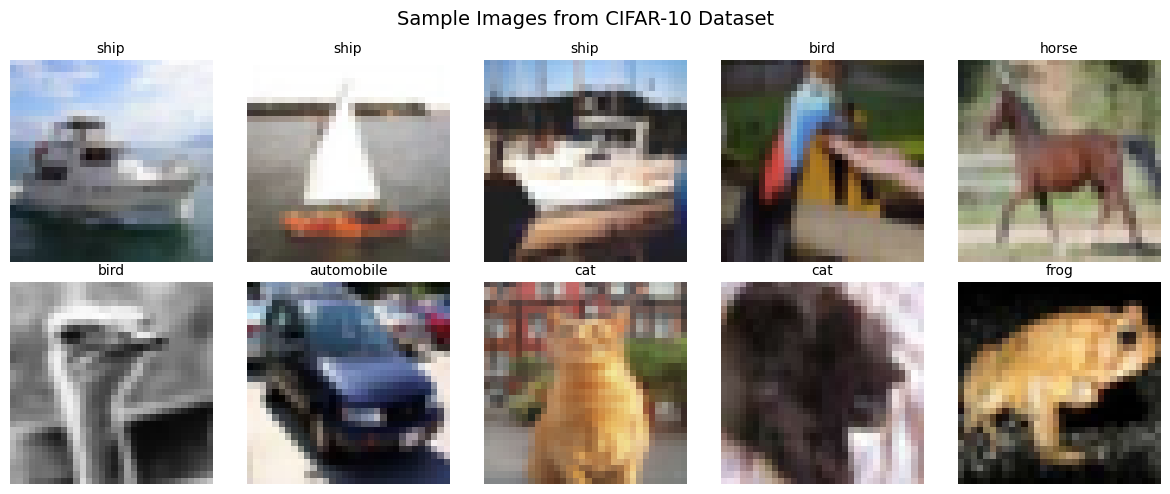

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Images from CIFAR-10 Dataset', fontsize=14)

for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(x_train))
    ax.imshow(x_train[idx])
    ax.set_title(class_names[y_train[idx][0]], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Section 3: Task 1 - Architectural Design

In this section, I build the core components of the Variational Autoencoder:

In [11]:
LATENT_DIM = 128
IMAGE_SHAPE = (32, 32, 3)

print(f"Latent Space Dimension: {LATENT_DIM}")
print(f"Input Image Shape: {IMAGE_SHAPE}")

class Sampling(layers.Layer):
    """
    Custom layer implementing the reparameterization trick.
    This allows gradients to flow through the sampling operation.
    """

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape=(batch, dim))

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

print("Sampling layer (Reparameterization Trick) defined successfully.")

Latent Space Dimension: 128
Input Image Shape: (32, 32, 3)
Sampling layer (Reparameterization Trick) defined successfully.


### 3.1 The Encoder

The encoder uses convolutional layers to progressively reduce spatial dimensions while increasing feature depth. The final output is flattened and passed through dense layers to produce z_mean and z_log_var parameters.

**Architecture:**
- 4 Convolutional blocks with increasing filters (32 → 64 → 128 → 256)
- Batch Normalization for training stability
- LeakyReLU activation for better gradient flow
- Dense layers outputting the mean and log-variance

In [12]:
def build_encoder(latent_dim):
    encoder_inputs = keras.Input(shape=IMAGE_SHAPE, name='encoder_input')

    x = layers.Conv2D(32, kernel_size=3, strides=2, padding='same')(encoder_inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2D(64, kernel_size=3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2D(128, kernel_size=3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2D(256, kernel_size=3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)

    z = Sampling()([z_mean, z_log_var])

    encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
    return encoder

encoder = build_encoder(LATENT_DIM)
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │        896 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_15      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 8, 8, 64)  │     18,496 │ leaky_re_lu_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_16      │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 4, 4, 128) │     73,856 │ leaky_re_lu_16[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4, 128) │        512 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_17      │ (None, 4, 4, 128) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 2, 2, 256) │    295,168 │ leaky_re_lu_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2, 2, 256) │      1,024 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_18      │ (None, 2, 2, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 1024)      │          0 │ leaky_re_lu_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │    524,800 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_19      │ (None, 512)       │          0 │ dense_3[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 128)       │     65,664 │ leaky_re_lu_19[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 128)       │     65,664 │ leaky_re_lu_19[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 128)       │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0] 

 Total params: 1,046,464 (3.99 MB)

 Trainable params: 1,045,504 (3.99 MB)

 Non-trainable params: 960 (3.75 KB)

### 3.2 The Decoder

The decoder mirrors the encoder architecture but in reverse. It takes a latent vector and upsamples it back to the original image dimensions using transposed convolutions (deconvolutions).

**Architecture:**
- Dense layer to reshape latent vector to spatial dimensions
- 4 Transposed Convolutional blocks with decreasing filters (256 -> 128 -> 64 -> 32)
- Batch Normalization for stable training
- Final convolution with sigmoid activation to produce pixel values in [0, 1]

In [ ]:
def build_decoder(latent_dim):
    latent_inputs = keras.Input(shape=(latent_dim,), name='decoder_input')

    x = layers.Dense(2 * 2 * 256)(latent_inputs)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Reshape((2, 2, 256))(x)

    x = layers.Conv2DTranspose(256, kernel_size=3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    decoder_outputs = layers.Conv2D(3, kernel_size=3, activation='sigmoid', padding='same', name='decoder_output')(x)

    decoder = Model(latent_inputs, decoder_outputs, name='decoder')
    return decoder

decoder = build_decoder(LATENT_DIM)
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       132,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 4, 4, 256)      │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 8, 8, 128)      │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_22 (LeakyReLU)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_23 (LeakyReLU)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_24 (LeakyReLU)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,112,259 (4.24 MB)

 Trainable params: 1,111,299 (4.24 MB)

 Non-trainable params: 960 (3.75 KB)

### 3.3 The Bridge (Reparameterization Trick)

The reparameterization trick is the key innovation that bridges the encoder and decoder. It enables backpropagation through the stochastic sampling operation.

Instead of sampling directly from the learned distribution N(mean, variance), I sample epsilon from a standard normal distribution N(0, 1) and compute:

**z = mean + exp(0.5 x log_var) x epsilon**

This reformulation moves the randomness to an external input (epsilon), making the entire pipeline differentiable. The `Sampling` layer (defined above) implements this trick as a custom Keras layer, allowing gradients to flow from the decoder through the sampling step back to the encoder during training.

### 3.4 Complete VAE Model

I now combine the encoder and decoder into a complete VAE model. The VAE class handles:
- Forward pass through encoder -> sampling -> decoder
- Computing the VAE loss (reconstruction loss + KL divergence)
- The beta parameter for controlling the KL divergence weight (used in Task 4)

In [ ]:
class VAE(keras.Model):
    """
    Variational Autoencoder combining encoder and decoder.
    Implements the VAE loss function with configurable beta parameter.
    """

    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta

        self.total_loss_tracker = keras.metrics.Mean(name='total_loss')
        self.reconstruction_loss_tracker = keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def call(self, inputs, training=False):
        """Forward pass through the VAE."""
        z_mean, z_log_var, z = self.encoder(inputs, training=training)
        reconstructed = self.decoder(z, training=training)
        return reconstructed

    def train_step(self, data):
        """Custom training step with VAE loss."""
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data, training=True)
            reconstruction = self.decoder(z, training=True)

            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(data, reconstruction)
            )

            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )

            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            'loss': self.total_loss_tracker.result(),
            'reconstruction_loss': self.reconstruction_loss_tracker.result(),
            'kl_loss': self.kl_loss_tracker.result()
        }

    def test_step(self, data):
        """Custom test step for validation."""
        z_mean, z_log_var, z = self.encoder(data, training=False)
        reconstruction = self.decoder(z, training=False)

        reconstruction_loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(data, reconstruction)
        )

        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )

        total_loss = reconstruction_loss + self.beta * kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            'loss': self.total_loss_tracker.result(),
            'reconstruction_loss': self.reconstruction_loss_tracker.result(),
            'kl_loss': self.kl_loss_tracker.result()
        }

print("VAE model class defined with:")
print(f"  - Encoder: {encoder.name}")
print(f"  - Decoder: {decoder.name}")
print(f"  - Loss: Reconstruction (BCE) + beta x KL Divergence")

VAE model class defined with:
  - Encoder: encoder
  - Decoder: decoder
  - Loss: Reconstruction (BCE) + β × KL Divergence


## Section 4: Task 2 - Training and Performance

In this section, I train the VAE model on the CIFAR-10 dataset.

In [ ]:
BATCH_SIZE = 128
EPOCHS = 50
LEARNING_RATE = 0.001

vae = VAE(encoder, decoder, beta=1.0)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))

callbacks = [
    ReduceLROnPlateau(
        monitor='loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

print("Training Configuration:")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Epochs: {EPOCHS}")
print(f"  - Learning Rate: {LEARNING_RATE}")
print(f"  - beta (KL weight): 1.0")

Training Configuration:
  - Batch Size: 128
  - Epochs: 50
  - Learning Rate: 0.001
  - β (KL weight): 1.0


In [16]:
print("Starting VAE training...")
print("=" * 50)

history = vae.fit(
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test,),
    callbacks=callbacks,
    verbose=1
)

print("=" * 50)
print("Training completed!")

Starting VAE training...
Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 79s 187ms/step - kl_loss: 0.0160 - loss: 0.6747 - reconstruction_loss: 0.6587 - val_kl_loss: 0.0118 - val_loss: 0.6663 - val_reconstruction_loss: 0.6545 - learning_rate: 0.0010
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 192ms/step - kl_loss: 0.0167 - loss: 0.6601 - reconstruction_loss: 0.6433 - val_kl_loss: 0.0229 - val_loss: 0.6646 - val_reconstruction_loss: 0.6417 - learning_rate: 0.0010
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 192ms/step - kl_loss: 0.0182 - loss: 0.6579 - reconstruction_loss: 0.6397 - val_kl_loss: 0.0227 - val_loss: 0.6636 - val_reconstruction_loss: 0.6409 - learning_rate: 0.0010
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1579s 4s/step - kl_loss: 0.0184 - loss: 0.6572 - reconstruction_loss: 0.6389 - val_kl_loss: 0.0215 - val_loss: 0.6604 - val_reconstruction_loss: 0.6388 - learning_rate: 0.0010
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 173s 442ms/step - kl_loss: 0.0185 - loss: 0.6570 - reconstruction_lo

### 4.1 Training Curves

Below I plot the training curves showing how the model's loss decreased over epochs.

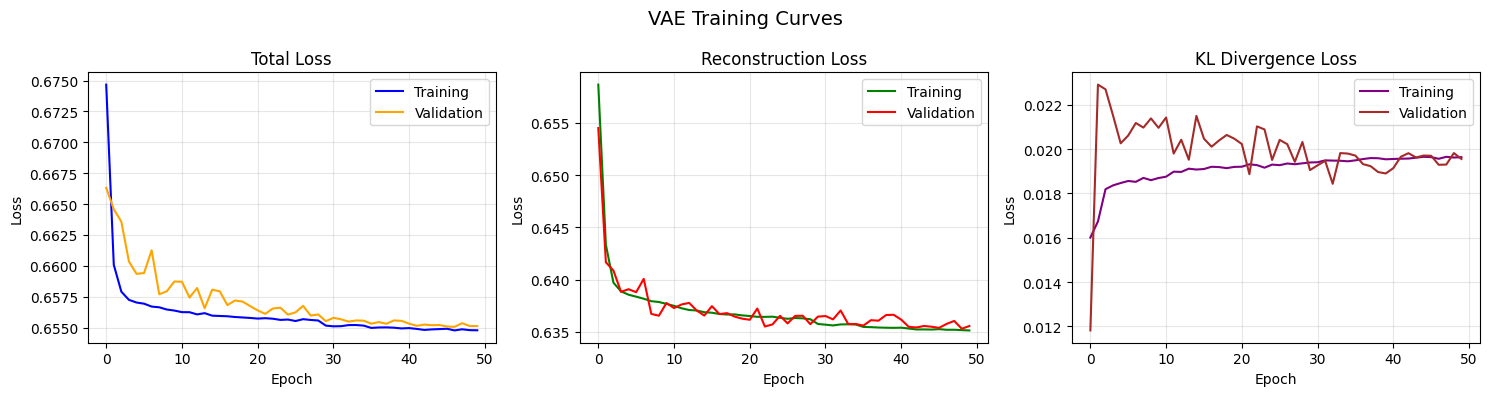


Final Training Loss: 0.6548
Final Validation Loss: 0.6551


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['loss'], label='Training', color='blue')
axes[0].plot(history.history['val_loss'], label='Validation', color='orange')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['reconstruction_loss'], label='Training', color='green')
axes[1].plot(history.history['val_reconstruction_loss'], label='Validation', color='red')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history.history['kl_loss'], label='Training', color='purple')
axes[2].plot(history.history['val_kl_loss'], label='Validation', color='brown')
axes[2].set_title('KL Divergence Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('VAE Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nFinal Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

### 4.2 Generated Images from Random Noise


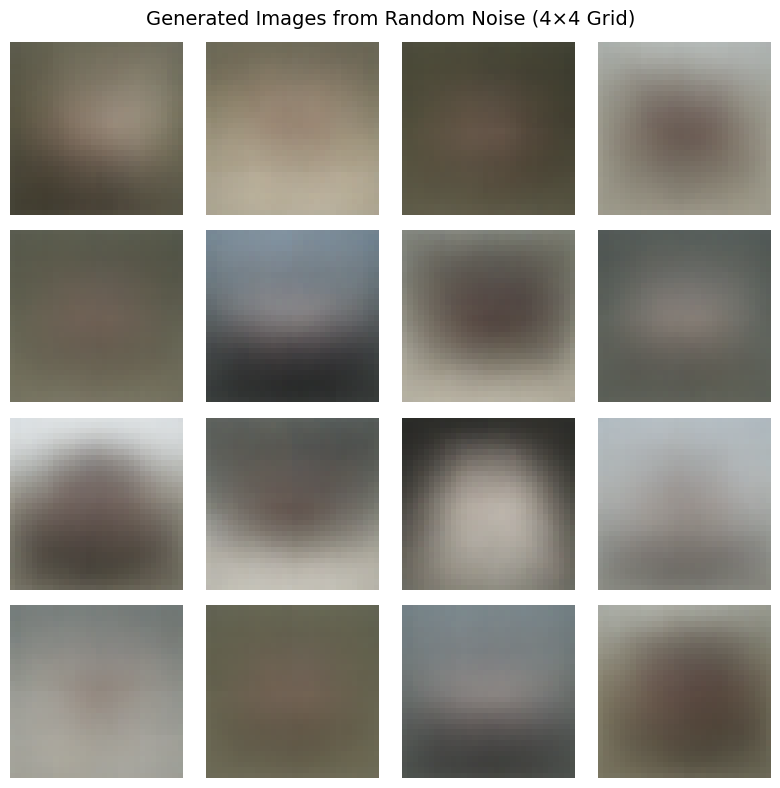

Successfully generated 16 images from random latent vectors.


In [ ]:
def generate_images(decoder, n_samples=16, latent_dim=LATENT_DIM):
    random_latent_vectors = np.random.normal(size=(n_samples, latent_dim))
    generated_images = decoder.predict(random_latent_vectors, verbose=0)
    return generated_images

generated = generate_images(decoder, n_samples=16)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle('Generated Images from Random Noise (4×4 Grid)', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Successfully generated 16 images from random latent vectors.")

### 4.3 Reconstruction Quality

I also visualize how well the model reconstructs test images by comparing original images with their reconstructions. This demonstrates the encoder-decoder pipeline working together.

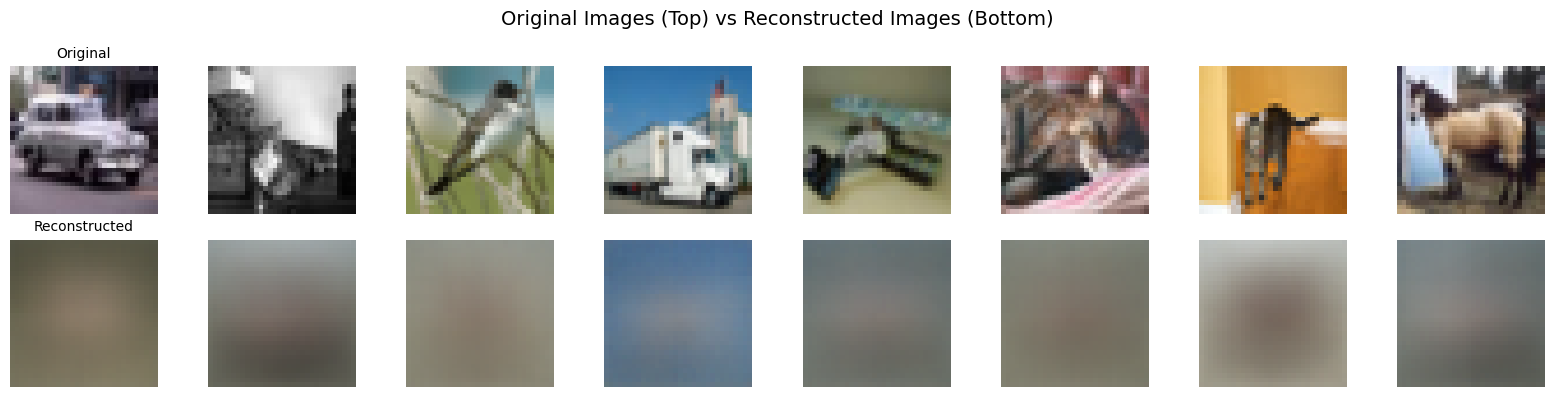

Reconstruction comparison displayed.


In [19]:
n_display = 8
indices = np.random.choice(len(x_test), n_display, replace=False)
sample_images = x_test[indices]

reconstructed = vae.predict(sample_images, verbose=0)

fig, axes = plt.subplots(2, n_display, figsize=(16, 4))
fig.suptitle('Original Images (Top) vs Reconstructed Images (Bottom)', fontsize=14)

for i in range(n_display):
    axes[0, i].imshow(sample_images[i])
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=10)

    axes[1, i].imshow(reconstructed[i])
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', fontsize=10)

plt.tight_layout()
plt.show()

print("Reconstruction comparison displayed.")

## Section 5: Task 3 - Latent Space Interpolation

In this section, I demonstrate the VAE's ability to smoothly transition between two different images by interpolating in the latent space.

In [20]:
def interpolate_latent_space(encoder, decoder, img1, img2, n_steps=10):

    img1 = np.expand_dims(img1, axis=0) if len(img1.shape) == 3 else img1
    img2 = np.expand_dims(img2, axis=0) if len(img2.shape) == 3 else img2

    z1, _, _ = encoder.predict(img1, verbose=0)
    z2, _, _ = encoder.predict(img2, verbose=0)

    interpolated_images = []
    for t in np.linspace(0, 1, n_steps):
        z_interp = (1 - t) * z1 + t * z2
        decoded = decoder.predict(z_interp, verbose=0)
        interpolated_images.append(decoded[0])

    return np.array(interpolated_images)

print("Latent space interpolation function defined.")

Latent space interpolation function defined.


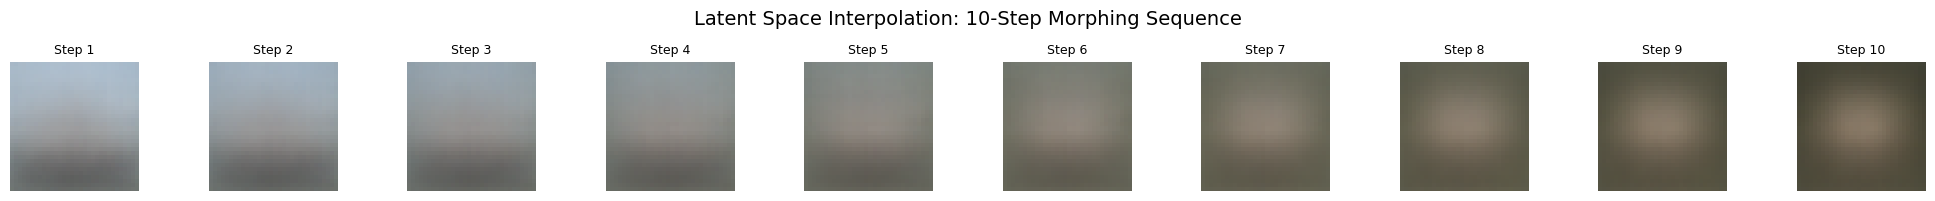

Interpolation from airplane to automobile completed.


In [21]:
class1_idx = np.where(y_test == 0)[0][0]
class2_idx = np.where(y_test == 1)[0][0]

img1 = x_test[class1_idx]
img2 = x_test[class2_idx]

interpolated = interpolate_latent_space(encoder, decoder, img1, img2, n_steps=10)

fig, axes = plt.subplots(1, 10, figsize=(20, 2))
fig.suptitle('Latent Space Interpolation: 10-Step Morphing Sequence', fontsize=14)

for i, ax in enumerate(axes):
    ax.imshow(interpolated[i])
    ax.axis('off')
    ax.set_title(f'Step {i+1}', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Interpolation from {class_names[0]} to {class_names[1]} completed.")

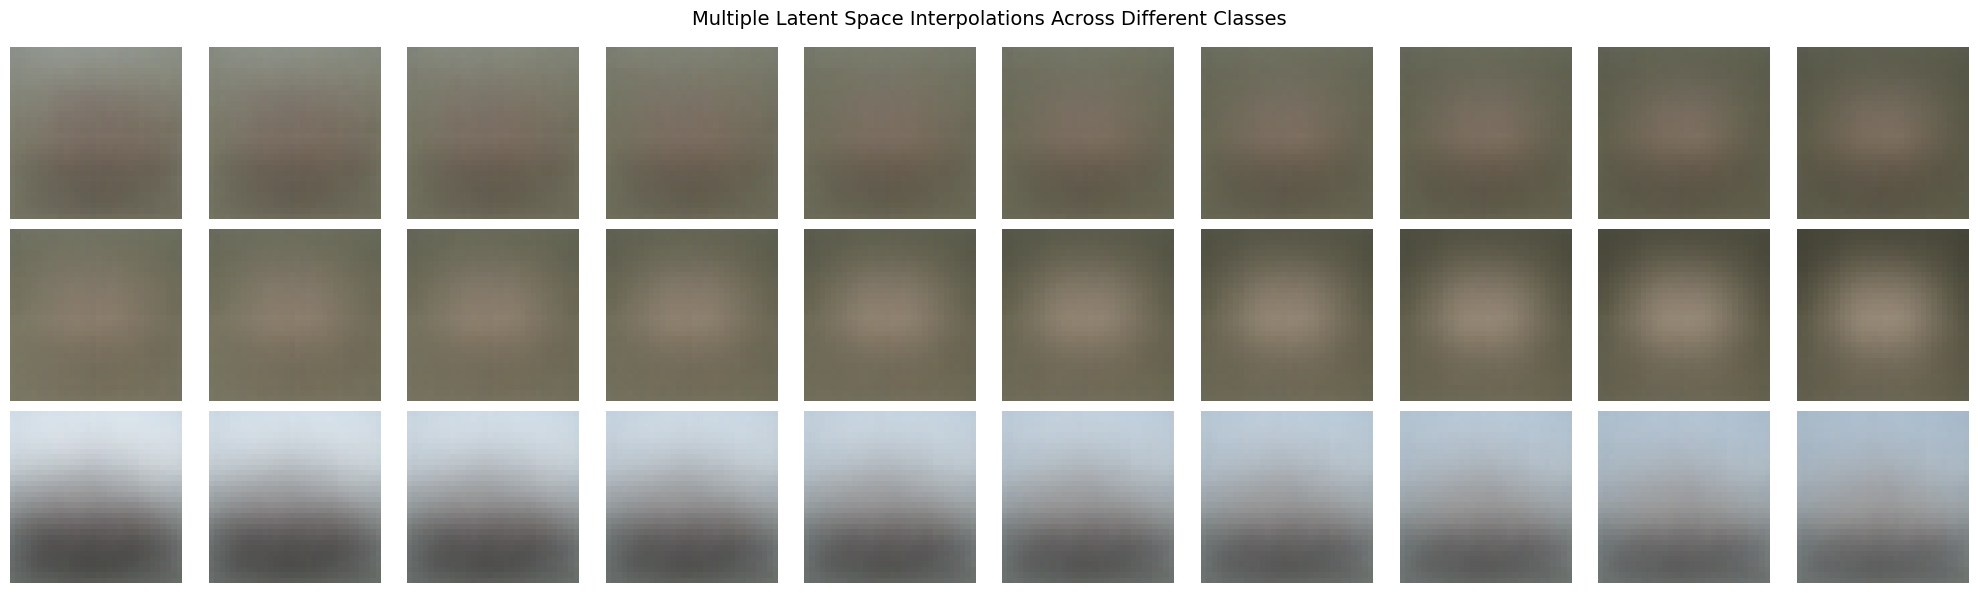

Multiple interpolation sequences displayed.


In [22]:
fig, axes = plt.subplots(3, 10, figsize=(20, 6))
fig.suptitle('Multiple Latent Space Interpolations Across Different Classes', fontsize=14)

class_pairs = [
    (2, 4),
    (3, 5),
    (8, 0),
]

for row, (c1, c2) in enumerate(class_pairs):
    idx1 = np.where(y_test == c1)[0][0]
    idx2 = np.where(y_test == c2)[0][0]

    interp = interpolate_latent_space(encoder, decoder, x_test[idx1], x_test[idx2], n_steps=10)

    for col in range(10):
        axes[row, col].imshow(interp[col])
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(f'{class_names[c1]}→{class_names[c2]}', fontsize=9)

plt.tight_layout()
plt.show()

print("Multiple interpolation sequences displayed.")

## Section 6: Task 4 - Beta-VAE Modification

In this section, I explore the effect of the beta parameter on the VAE's behavior. The beta-VAE modifies the standard VAE loss by weighting the KL divergence term:

**Loss = Reconstruction Loss + beta x KL Divergence**

In [ ]:
print("Building beta-VAE with beta=5...")
print("=" * 50)

encoder_beta = build_encoder(LATENT_DIM)
decoder_beta = build_decoder(LATENT_DIM)

vae_beta5 = VAE(encoder_beta, decoder_beta, beta=5.0)
vae_beta5.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))

print(f"beta-VAE created with beta = 5.0")
print("Training beta-VAE...")

Building β-VAE with β=5...
β-VAE created with β = 5.0
Training β-VAE...


In [ ]:
history_beta5 = vae_beta5.fit(
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test,),
    callbacks=[
        ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        EarlyStopping(monitor='loss', patience=10, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

print("=" * 50)
print("beta-VAE (beta=5) training completed!")

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 54s 131ms/step - kl_loss: 0.0036 - loss: 0.7056 - reconstruction_loss: 0.6874 - val_kl_loss: 0.0011 - val_loss: 0.6909 - val_reconstruction_loss: 0.6853 - learning_rate: 0.0010
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 49s 124ms/step - kl_loss: 0.0016 - loss: 0.6879 - reconstruction_loss: 0.6801 - val_kl_loss: 0.0016 - val_loss: 0.6889 - val_reconstruction_loss: 0.6810 - learning_rate: 0.0010
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - kl_loss: 0.0016 - loss: 0.6876 - reconstruction_loss: 0.6796 - val_kl_loss: 0.0012 - val_loss: 0.6877 - val_reconstruction_loss: 0.6815 - learning_rate: 0.0010
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 122ms/step - kl_loss: 0.0016 - loss: 0.6874 - reconstruction_loss: 0.6795 - val_kl_loss: 0.0013 - val_loss: 0.6875 - val_reconstruction_loss: 0.6812 - learning_rate: 0.0010
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 49s 124ms/step - kl_loss: 0.0016 - loss: 0.6874 - reconstruction_loss: 0.6796 - val_kl_loss:

### 6.1 Comparison: beta=1 vs beta=5

Below I compare the generated images from both models to visualize the impact of increasing the beta parameter on image quality.

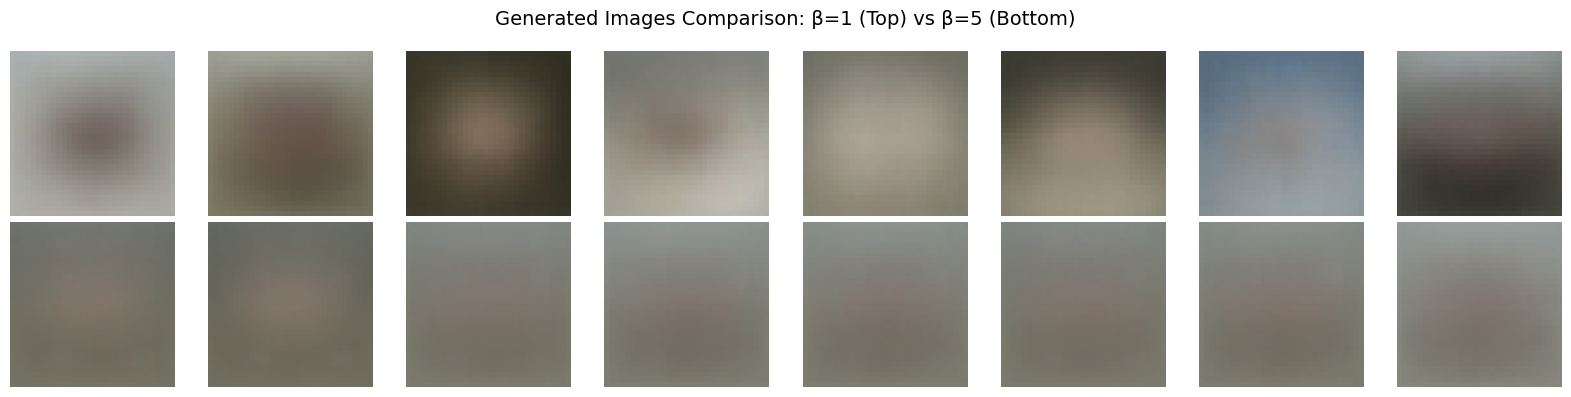

In [ ]:
np.random.seed(123)
random_vectors = np.random.normal(size=(8, LATENT_DIM))

generated_beta1 = decoder.predict(random_vectors, verbose=0)

generated_beta5 = decoder_beta.predict(random_vectors, verbose=0)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Generated Images Comparison: beta=1 (Top) vs beta=5 (Bottom)', fontsize=14)

for i in range(8):
    axes[0, i].imshow(generated_beta1[i])
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('beta=1', fontsize=11)

    axes[1, i].imshow(generated_beta5[i])
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('beta=5', fontsize=11)

plt.tight_layout()
plt.show()

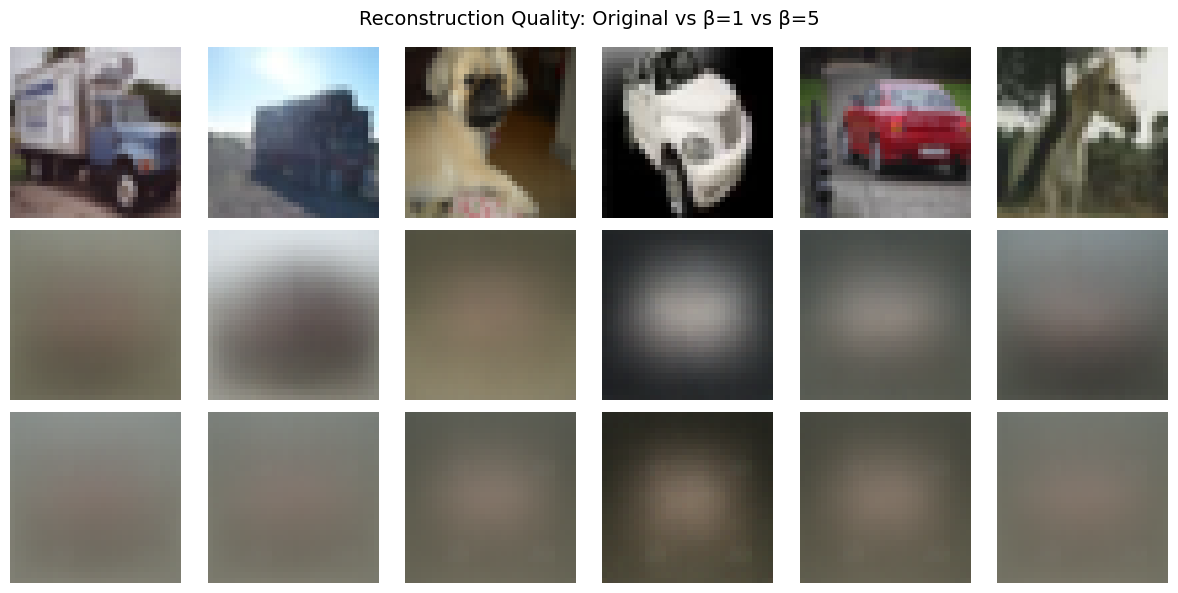

In [ ]:
sample_indices = np.random.choice(len(x_test), 6, replace=False)
sample_images = x_test[sample_indices]

recon_beta1 = vae.predict(sample_images, verbose=0)
recon_beta5 = vae_beta5.predict(sample_images, verbose=0)

fig, axes = plt.subplots(3, 6, figsize=(12, 6))
fig.suptitle('Reconstruction Quality: Original vs beta=1 vs beta=5', fontsize=14)

for i in range(6):
    axes[0, i].imshow(sample_images[i])
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=10)

    axes[1, i].imshow(recon_beta1[i])
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('beta=1', fontsize=10)

    axes[2, i].imshow(recon_beta5[i])
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('beta=5', fontsize=10)

plt.tight_layout()
plt.show()

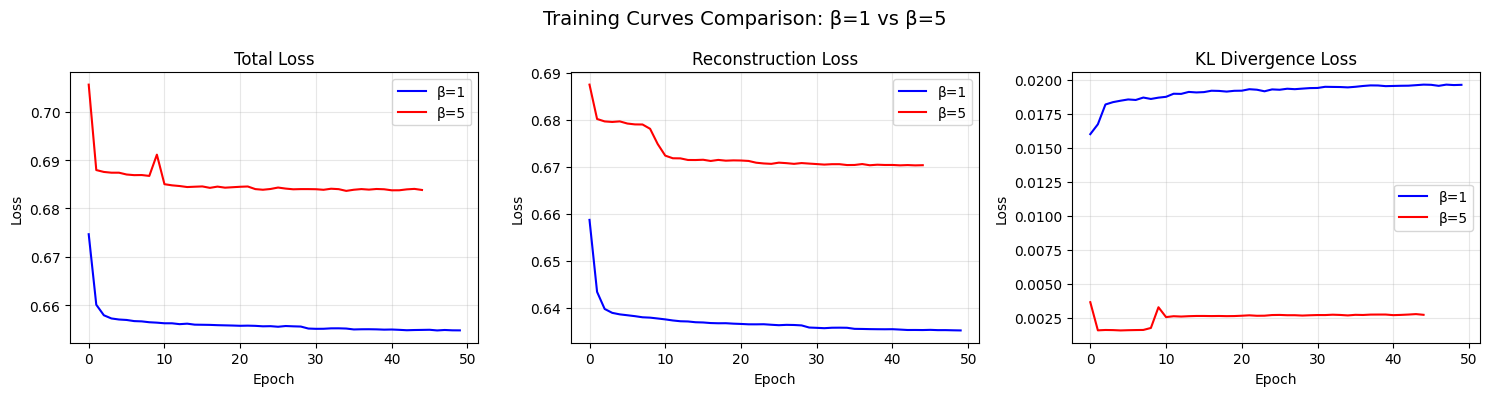


Final Metrics Comparison:
Metric                    β=1             β=5            
Total Loss                0.6548          0.6838         
Reconstruction Loss       0.6351          0.6703         
KL Loss                   0.0196          0.0027         


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Training Curves Comparison: beta=1 vs beta=5', fontsize=14)

axes[0].plot(history.history['loss'], label='beta=1', color='blue')
axes[0].plot(history_beta5.history['loss'], label='beta=5', color='red')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['reconstruction_loss'], label='beta=1', color='blue')
axes[1].plot(history_beta5.history['reconstruction_loss'], label='beta=5', color='red')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history.history['kl_loss'], label='beta=1', color='blue')
axes[2].plot(history_beta5.history['kl_loss'], label='beta=5', color='red')
axes[2].set_title('KL Divergence Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFinal Metrics Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'beta=1':<15} {'beta=5':<15}")
print("=" * 50)
print(f"{'Total Loss':<25} {history.history['loss'][-1]:<15.4f} {history_beta5.history['loss'][-1]:<15.4f}")
print(f"{'Reconstruction Loss':<25} {history.history['reconstruction_loss'][-1]:<15.4f} {history_beta5.history['reconstruction_loss'][-1]:<15.4f}")
print(f"{'KL Loss':<25} {history.history['kl_loss'][-1]:<15.4f} {history_beta5.history['kl_loss'][-1]:<15.4f}")

**Conclusion**

In this assignment, I built and trained a convolutional Variational Autoencoder (VAE) on the CIFAR-10 dataset (32x32 RGB images). The model used four convolutional layers in the encoder, a mirrored decoder, and a 128-dimensional latent space with the reparameterization trick for end-to-end training.

With beta = 1, the model trained well and showed no overfitting. It captured overall shapes and colors in the images, but the outputs were slightly blurry, which is a known limitation of VAEs using pixel-wise reconstruction loss. Latent space interpolation between different classes produced smooth transitions, confirming that the model learned a meaningful and continuous latent representation.

When increasing beta to 5 (beta-VAE), the KL divergence decreased significantly, meaning the latent space became more structured. However, reconstruction quality dropped and images became blurrier. This demonstrates the trade-off in beta-VAE: stronger latent regularization leads to poorer reconstruction quality.

Overall, this experiment helped me understand how VAEs balance reconstruction accuracy and latent space regularization.